In [1]:
import sys
import os
# setup work directory
current_dir = os.getcwd()
work_dir = os.path.abspath(os.path.join(current_dir, "../"))
os.chdir(work_dir)
sys.path.append(work_dir)
work_dir

'c:\\Project_HOME\\pyradar'

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


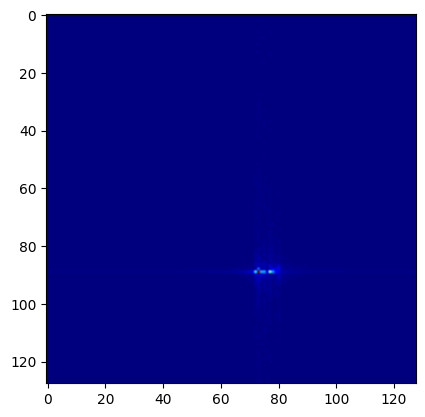

In [2]:
from pyradar_sandbox.sim.demo_sim import generate_sphere_point_cloud, generate_linear_trajectory, radar_simulation, animate_range_images_with_3d
import numpy as np
from pyradar_sandbox.cfg.TI_1843 import ColoradarTI1843BoostConfig
from pyradar_sandbox.utils.vis import range_doppler_map

import matplotlib.pyplot as plt



radar_config = ColoradarTI1843BoostConfig()
sim_adc = np.zeros((radar_config.numChirpsPerFrame, radar_config.numADCSamples), dtype=np.complex64)  # Simulated ADC output
scene_points, pts_rcs = generate_sphere_point_cloud(center=np.array([10, 1, 0]), radius=1.0)
trajectory = generate_linear_trajectory(n_frames=radar_config.numChirpsPerFrame)
for idxChirp in range(radar_config.numChirpsPerFrame):
    RX_pose = trajectory[idxChirp]  # Get the antenna pose for this chirp
    sim_adc[idxChirp] = radar_simulation(
        scene_points, 
        pts_rcs,
        RX_pose,
        radar_config=radar_config
    )

sim_spectrum = range_doppler_map(adc_cube=sim_adc[..., np.newaxis], IdxChirps=0, IdxSamples=1)  # Take magnitude of the complex ADC output
plt.imshow(np.abs(sim_spectrum), cmap='jet')
plt.show()
